# 03 — Primeiro gráfico: a série de `PercentualdeDevolucao`

**Objetivo:** plotar o percentual de devolução mês a mês e escrever o que o
gráfico mostra — e o que ele não mostra.

Faz parte da [etapa 4](../README.md#progresso) do projeto. A base já foi validada nas
etapas 2 e 3: completa (52 meses, sem lacuna) e com a fórmula confirmada.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ivadivad/med-em-numeros/main/dados/fraude.csv"
df = pd.read_csv(URL)
df["Data"] = pd.to_datetime(df["AnoMes"], format="%Y%m")
df = df.sort_values("Data").reset_index(drop=True)
df[["Data", "PercentualdeDevolucao"]].head()

,Data,PercentualdeDevolucao
0,2022-01-01,5.29
1,2022-02-01,5.99
2,2022-03-01,7.84
3,2022-04-01,6.78
4,2022-05-01,5.49


## Primeiro gráfico, sem ajuste nenhum

<Axes: xlabel='Data'>

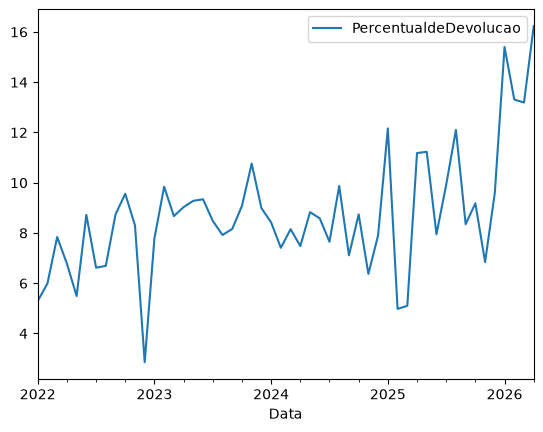

In [2]:
df.plot(x="Data", y="PercentualdeDevolucao")

Funciona, mas não diz nada sozinho: eixo Y começa perto de 3 em vez de zero
(exagera a variação visualmente), não tem título, a legenda ("PercentualdeDevolucao")
é o nome da coluna, não uma frase, e as bordas de cima e da direita não
ajudam em nada.

## Com eixo e título ajustados

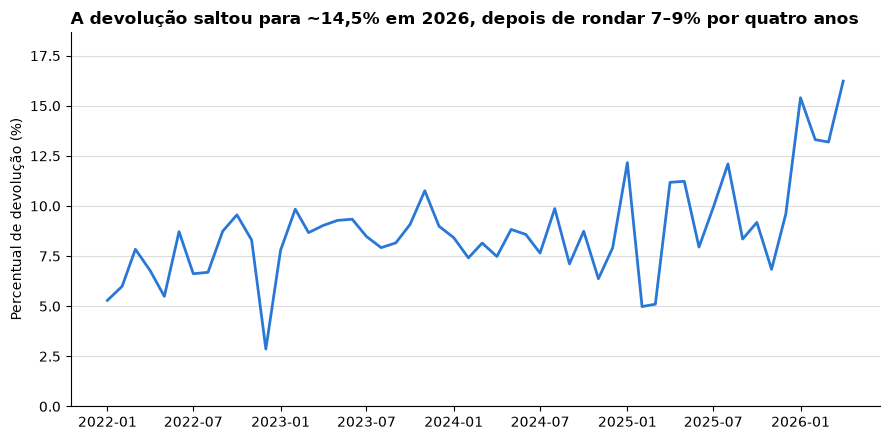

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(df["Data"], df["PercentualdeDevolucao"], color="#2a78d6", linewidth=2)

ax.set_ylim(0, df["PercentualdeDevolucao"].max() * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.set_title(
    "A devolução saltou para ~14,5% em 2026, depois de rondar 7–9% por quatro anos",
    loc="left", fontsize=12, fontweight="bold"
)
ax.set_xlabel("")
ax.set_ylabel("Percentual de devolução (%)")

plt.tight_layout()
plt.savefig("../graficos/03-percentual-devolucao.png", dpi=150)
plt.show()

## O que o gráfico mostra — e o que não mostra

**Mostra:**

- O percentual de devolução ficou entre 2,9% e 9,9% em praticamente toda a
  série (2022 a 2025), com média anual subindo devagar ano a ano (6,9% → 8,9%
  → 8,0% → 9,0%).
- Os quatro primeiros meses de 2026 destoam claramente do resto: 13,2% a
  16,2%, bem acima do teto dos quatro anos anteriores.

**Não mostra** (e seria erro ler como se mostrasse):

- **Por que** a devolução subiu em 2026. O gráfico descreve uma mudança, não
  explica — essa é a etapa 6 (contexto regulatório), que ainda não foi feita.
- Se o patamar de 2026 **vai se manter**. São só 4 meses contra 48 dos anos
  anteriores — amostra pequena demais pra chamar de tendência consolidada.
- O **volume** por trás do percentual. Um percentual mais alto sobre uma base
  de contestações maior (a etapa 5 mostra que elas cresceram muito a partir
  de out/2025) não é a mesma coisa que um percentual mais alto sobre uma base
  estável. Isso ainda não foi separado aqui.

---

## Volume de contestações

A série de `PercentualdeDevolucao` não existe isolada — ela é uma razão entre
contestações aceitas/rejeitadas e valores devolvidos. Antes de ir pra causa
(etapa 6), vale olhar o volume por trás do percentual: quantas contestações
chegam por mês, quantas são aceitas, e se isso mudou de patamar em algum
ponto.

Faz parte da [etapa 5](../README.md#progresso) do projeto.

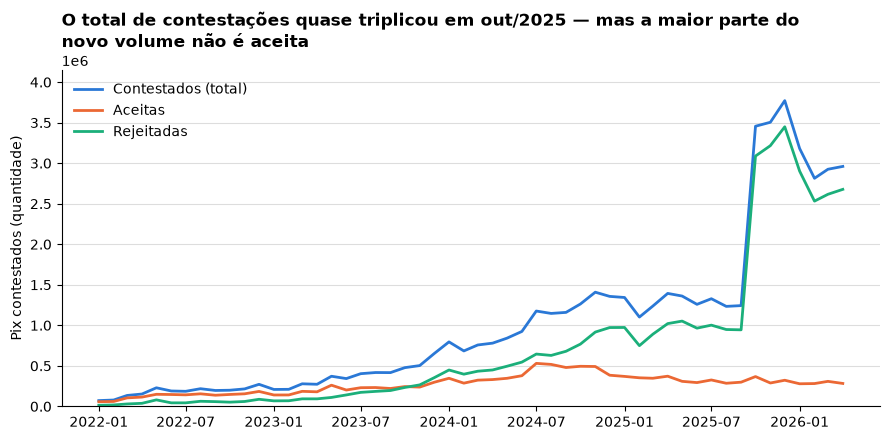

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(df["Data"], df["QtdePixcontestados"], color="#2a78d6", linewidth=2, label="Contestados (total)")
ax.plot(df["Data"], df["Qtdecontestacoesaceitas"], color="#eb6834", linewidth=2, label="Aceitas")
ax.plot(df["Data"], df["Qtdecontestacoesrejeitadas"], color="#1baf7a", linewidth=2, label="Rejeitadas")

ax.set_ylim(0, df["QtdePixcontestados"].max() * 1.1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.set_title(
    "O total de contestações quase triplicou em out/2025 — mas a maior parte do\nnovo volume não é aceita",
    loc="left", fontsize=12, fontweight="bold"
)
ax.set_ylabel("Pix contestados (quantidade)")
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig("../graficos/03-volume-contestacoes.png", dpi=150)
plt.show()

## Taxa de aceite

`Qtdecontestacoesaceitas / QtdePixcontestados` — já confirmamos na etapa 2 que
aceitas + rejeitadas somam exatamente o total, então a taxa de aceite e a taxa
de rejeição são complementares (uma é 100% menos a outra).

In [5]:
df["taxa_aceite"] = df["Qtdecontestacoesaceitas"] / df["QtdePixcontestados"] * 100
df[["Data", "taxa_aceite"]].describe()

,Data,taxa_aceite
count,52,52.000000
mean,2024-02-15 08:18:27.692307,45.681307
min,2022-01-01 00:00:00,8.233267
25%,2023-01-24 06:00:00,27.329490
50%,2024-02-15 12:00:00,44.348693
75%,2025-03-08 18:00:00,67.117842
max,2026-04-01 00:00:00,80.797953
std,NaN,22.535029


## Média móvel de 3 meses

A taxa de aceite mês a mês é ruidosa. Uma média móvel de 3 meses separa
tendência de ruído — sem ela, fica difícil dizer se uma queda é mudança real
ou só o mês ter sido atípico.

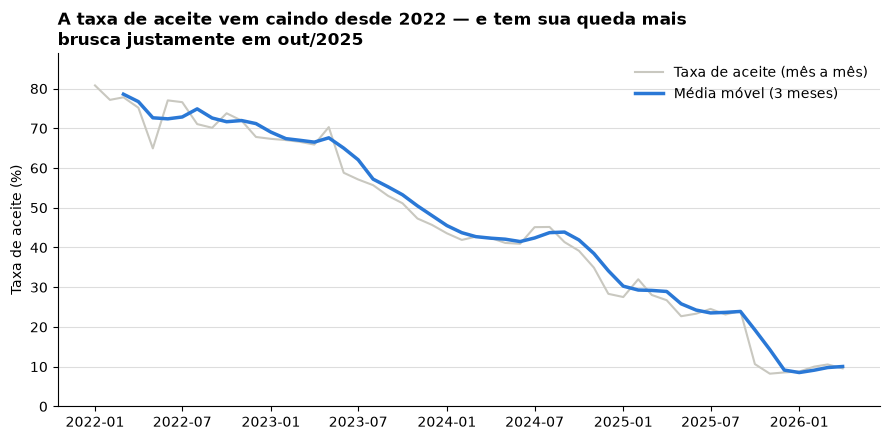

In [6]:
df["taxa_aceite_mm3"] = df["taxa_aceite"].rolling(3).mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["Data"], df["taxa_aceite"], color="#c9c8c0", linewidth=1.5, label="Taxa de aceite (mês a mês)")
ax.plot(df["Data"], df["taxa_aceite_mm3"], color="#2a78d6", linewidth=2.5, label="Média móvel (3 meses)")

ax.set_ylim(0, df["taxa_aceite"].max() * 1.1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

ax.set_title("A taxa de aceite vem caindo desde 2022 — e tem sua queda mais\nbrusca justamente em out/2025", loc="left", fontsize=12, fontweight="bold")
ax.set_ylabel("Taxa de aceite (%)")
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("../graficos/03-taxa-aceite.png", dpi=150)
plt.show()

## Identificando a quebra na série

`pct_change()` acha o maior salto relativo mês a mês — mas "salto" pode
querer dizer coisas diferentes dependendo da série. Aplico nas duas: no
volume total (onde espero um pico pontual) e na taxa de aceite (onde já vi no
gráfico acima que existe uma queda longa, não só um ponto).

In [7]:
variacao_volume = df["QtdePixcontestados"].pct_change() * 100
mes_quebra_volume = df.loc[variacao_volume.idxmax(), "AnoMes"]
print(f"maior salto no volume: {variacao_volume.max():.1f}% no mês {int(mes_quebra_volume)}")

queda_taxa = df["taxa_aceite"].diff()
mes_queda_taxa = df.loc[queda_taxa.idxmin(), "AnoMes"]
print(f"maior queda (pp) na taxa de aceite: {queda_taxa.min():.1f} pp no mês {int(mes_queda_taxa)}")

maior salto no volume: 178.0% no mês 202510
maior queda (pp) na taxa de aceite: -13.4 pp no mês 202510


## O achado

**As duas quebras caem no mesmo mês — out/2025 — mas são achados diferentes,
e um deles quase virou conclusão errada.**

- **Volume: uma quebra de verdade.** O salto de 178% no total de contestações
  é o maior da série, por larga margem, e não é um pico isolado: o volume
  passa de ~1,24 milhão/mês pra ~3,46 milhões/mês e **se mantém** nesse novo
  patamar nos meses seguintes.
- **Taxa de aceite: não é uma quebra, é uma tendência de 4 anos que acelera.**
  O gráfico da média móvel mostra a taxa caindo continuamente desde janeiro de
  2022 (~81%) até setembro de 2025 (~24%) — isso já vinha acontecendo bem
  antes do salto de volume. O que é verdade sobre out/2025 especificamente: a
  queda de −13,4 pontos percentuais naquele único mês é a maior queda mensal
  de toda a série (a segunda maior, −11,5 pp em jun/2023, fica longe). Então
  out/2025 acelera uma tendência que já existia, não a inaugura.

**Por que a primeira versão deste achado estava errada:** o título do
primeiro gráfico desta seção dizia que a taxa "caiu de ~24% pra menos de 10%
a partir de out/2025" — tecnicamente certo nos números, mas a frase dá a
entender que a queda começa ali. O gráfico da própria média móvel contradisse
isso antes de eu commitar: a linha já vinha descendo havia 44 meses.

**O que isso sugere, sem ainda explicar:** o volume subiu muito mais rápido
que a capacidade (ou o critério) de aceitar contestações como fraude
legítima — mas essa tensão entre volume e aceite já vinha crescendo havia
anos, out/2025 só a agudizou de uma vez. Por que o volume saltou especificamente
nesse mês é pergunta pra fonte externa, não pro dado: **etapa 6**, contexto
regulatório.